# CC_Plot_strip_IS_4regime_member67

Task 3: 4-regime ice-sheet strip plot for **member 67 only** (index 66), site LA.

Regime assigned per time step from the deterministic (single-member) values:

| Regime | Condition |
|--------|-----------|
| Aerial + ice | GSL ≥ −28 m AND ice_sheet ≥ 1 |
| Aerial + no ice | GSL ≥ −28 m AND ice_sheet < 1 |
| Under sea + ice | GSL < −28 m AND ice_sheet ≥ 1 |
| Under sea + no ice | GSL < −28 m AND ice_sheet < 1 |

Each time step is coloured by its regime; no ensemble stacking, no pie chart.

Generated by Claude Code (CC_ prefix rule).
Source notebooks: `CC_Plot_strip_IS_member67.ipynb` (Task 1) and `CC_Plot_strip_IS_4regime.ipynb` (Task 2).

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
variables  = ["temp", "precip", "evap", "soiltemp", "sm",
              "snowdepth", "LAI_PFT", "windspeed", "iceconc", "ice_sheet"]
var        = 9          # ice_sheet
site       = "_LA"
member_idx = 66         # member 67 (0-indexed)
ice_thresh = 1.0        # values >= threshold → ice present
gsl_thresh = -28.0      # m; below this → under sea

scenarios   = ["natural", "SSP126", "SSP245", "SSP370", "SSP585", "10000PGC"]
scen_labels = ["Natural", "SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5", "10,000 PgC"]

# Regime integer codes
REGIME_AERIAL_NOICE   = 0
REGIME_AERIAL_ICE     = 1
REGIME_UNDERSEA_NOICE = 2
REGIME_UNDERSEA_ICE   = 3

COLOR_AERIAL_ICE      = 'grey'
COLOR_AERIAL_NOICE    = 'green'
COLOR_UNDERSEA_ICE    = 'white'
COLOR_UNDERSEA_NOICE  = 'skyblue'

STACK_ORDER  = ['aerial_noice', 'aerial_ice', 'undersea_noice', 'undersea_ice']
STACK_COLORS = [COLOR_AERIAL_NOICE, COLOR_AERIAL_ICE,
                COLOR_UNDERSEA_NOICE, COLOR_UNDERSEA_ICE]
STACK_LABELS = ['Aerial, no ice sheet', 'Aerial, ice sheet',
                'Under sea, no ice sheet', 'Under sea, ice sheet']

ice_data_path = "site_data/"

gsl_data_path = "../2_GSL_model/results/emul_inputs_updatedCO2/"

out_path = "plots/ice_sheet_site_LA_4regime_member67.png"

In [31]:
# ── Load ice_sheet data for member 67 ────────────────────────────────────────
ice_member = {}   # {scen_idx: 1-D float array, length 1001}

for scen_idx, scen in enumerate(scenarios):
    fpath = f"{ice_data_path}site{site}/{variables[var]}_{scen}_site{site}.txt"
    print(f"Loading ice_sheet [{scen}] ...")
    data = np.loadtxt(fpath)                 # shape (90, 1001)
    ice_member[scen_idx] = data[member_idx, :]  # (1001,)
    print(f"  shape: {data.shape}")

Loading ice_sheet [natural] ...
  shape: (90, 1001)
Loading ice_sheet [SSP126] ...
  shape: (90, 1001)
Loading ice_sheet [SSP245] ...
  shape: (90, 1001)
Loading ice_sheet [SSP370] ...
  shape: (90, 1001)
Loading ice_sheet [SSP585] ...
  shape: (90, 1001)
Loading ice_sheet [10000PGC] ...
  shape: (90, 1001)


In [32]:
# ── Load GSL data for member 67 ───────────────────────────────────────────────
gsl_member = {}   # {scen_idx: 1-D float array, length 1001}
member_num = member_idx + 1   # file numbering is 1-based → 67

for scen_idx, scen in enumerate(scenarios):
    fpath = f"{gsl_data_path}emul_inputs_{scen}.{member_num}.updated.res"
    print(f"Loading GSL [{scen}] member {member_num} ...")
    df = pd.read_csv(fpath, sep=r'\s+', header=0)
    gsl_member[scen_idx] = df['ice'].values   # (1001,)
    print(f"  GSL range [{gsl_member[scen_idx].min():.1f}, {gsl_member[scen_idx].max():.1f}] m")

Loading GSL [natural] member 67 ...
  GSL range [-128.9, 4.3] m
Loading GSL [SSP126] member 67 ...
  GSL range [-123.8, 5.6] m
Loading GSL [SSP245] member 67 ...
  GSL range [-123.4, 15.9] m
Loading GSL [SSP370] member 67 ...
  GSL range [-122.1, 24.0] m
Loading GSL [SSP585] member 67 ...
  GSL range [-120.7, 24.0] m
Loading GSL [10000PGC] member 67 ...
  GSL range [-116.6, 24.0] m


In [33]:
# ── Classify each time step into one of 4 regimes ────────────────────────────
regime_member = {}   # {scen_idx: 1-D int array, length 1001, values 0..3}

for scen_idx in range(len(scenarios)):
    ice = ice_member[scen_idx]
    gsl = gsl_member[scen_idx]

    ice_present = ice >= ice_thresh   # bool (1001,)
    undersea    = gsl <  gsl_thresh   # bool (1001,)

    regime = np.full(len(ice), REGIME_AERIAL_NOICE, dtype=int)
    regime[ ~undersea &  ice_present] = REGIME_AERIAL_ICE
    regime[  undersea & ~ice_present] = REGIME_UNDERSEA_NOICE
    regime[  undersea &  ice_present] = REGIME_UNDERSEA_ICE

    regime_member[scen_idx] = regime

    # Print time fractions for each regime
    n = len(ice)
    print(f"{scen_labels[scen_idx]:12s} — "
          f"aerial+noice={np.sum(regime==REGIME_AERIAL_NOICE)/n*100:.1f}%  "
          f"aerial+ice={np.sum(regime==REGIME_AERIAL_ICE)/n*100:.1f}%  "
          f"undersea+noice={np.sum(regime==REGIME_UNDERSEA_NOICE)/n*100:.1f}%  "
          f"undersea+ice={np.sum(regime==REGIME_UNDERSEA_ICE)/n*100:.1f}%")

Natural      — aerial+noice=22.9%  aerial+ice=0.0%  undersea+noice=77.1%  undersea+ice=0.0%
SSP1-2.6     — aerial+noice=25.0%  aerial+ice=0.0%  undersea+noice=75.0%  undersea+ice=0.0%
SSP2-4.5     — aerial+noice=32.1%  aerial+ice=0.0%  undersea+noice=67.9%  undersea+ice=0.0%
SSP3-7.0     — aerial+noice=41.4%  aerial+ice=0.0%  undersea+noice=58.5%  undersea+ice=0.1%
SSP5-8.5     — aerial+noice=44.6%  aerial+ice=0.0%  undersea+noice=55.4%  undersea+ice=0.0%
10,000 PgC   — aerial+noice=63.6%  aerial+ice=0.0%  undersea+noice=36.4%  undersea+ice=0.0%


Saved to: plots/ice_sheet_site_LA_4regime_member67.png


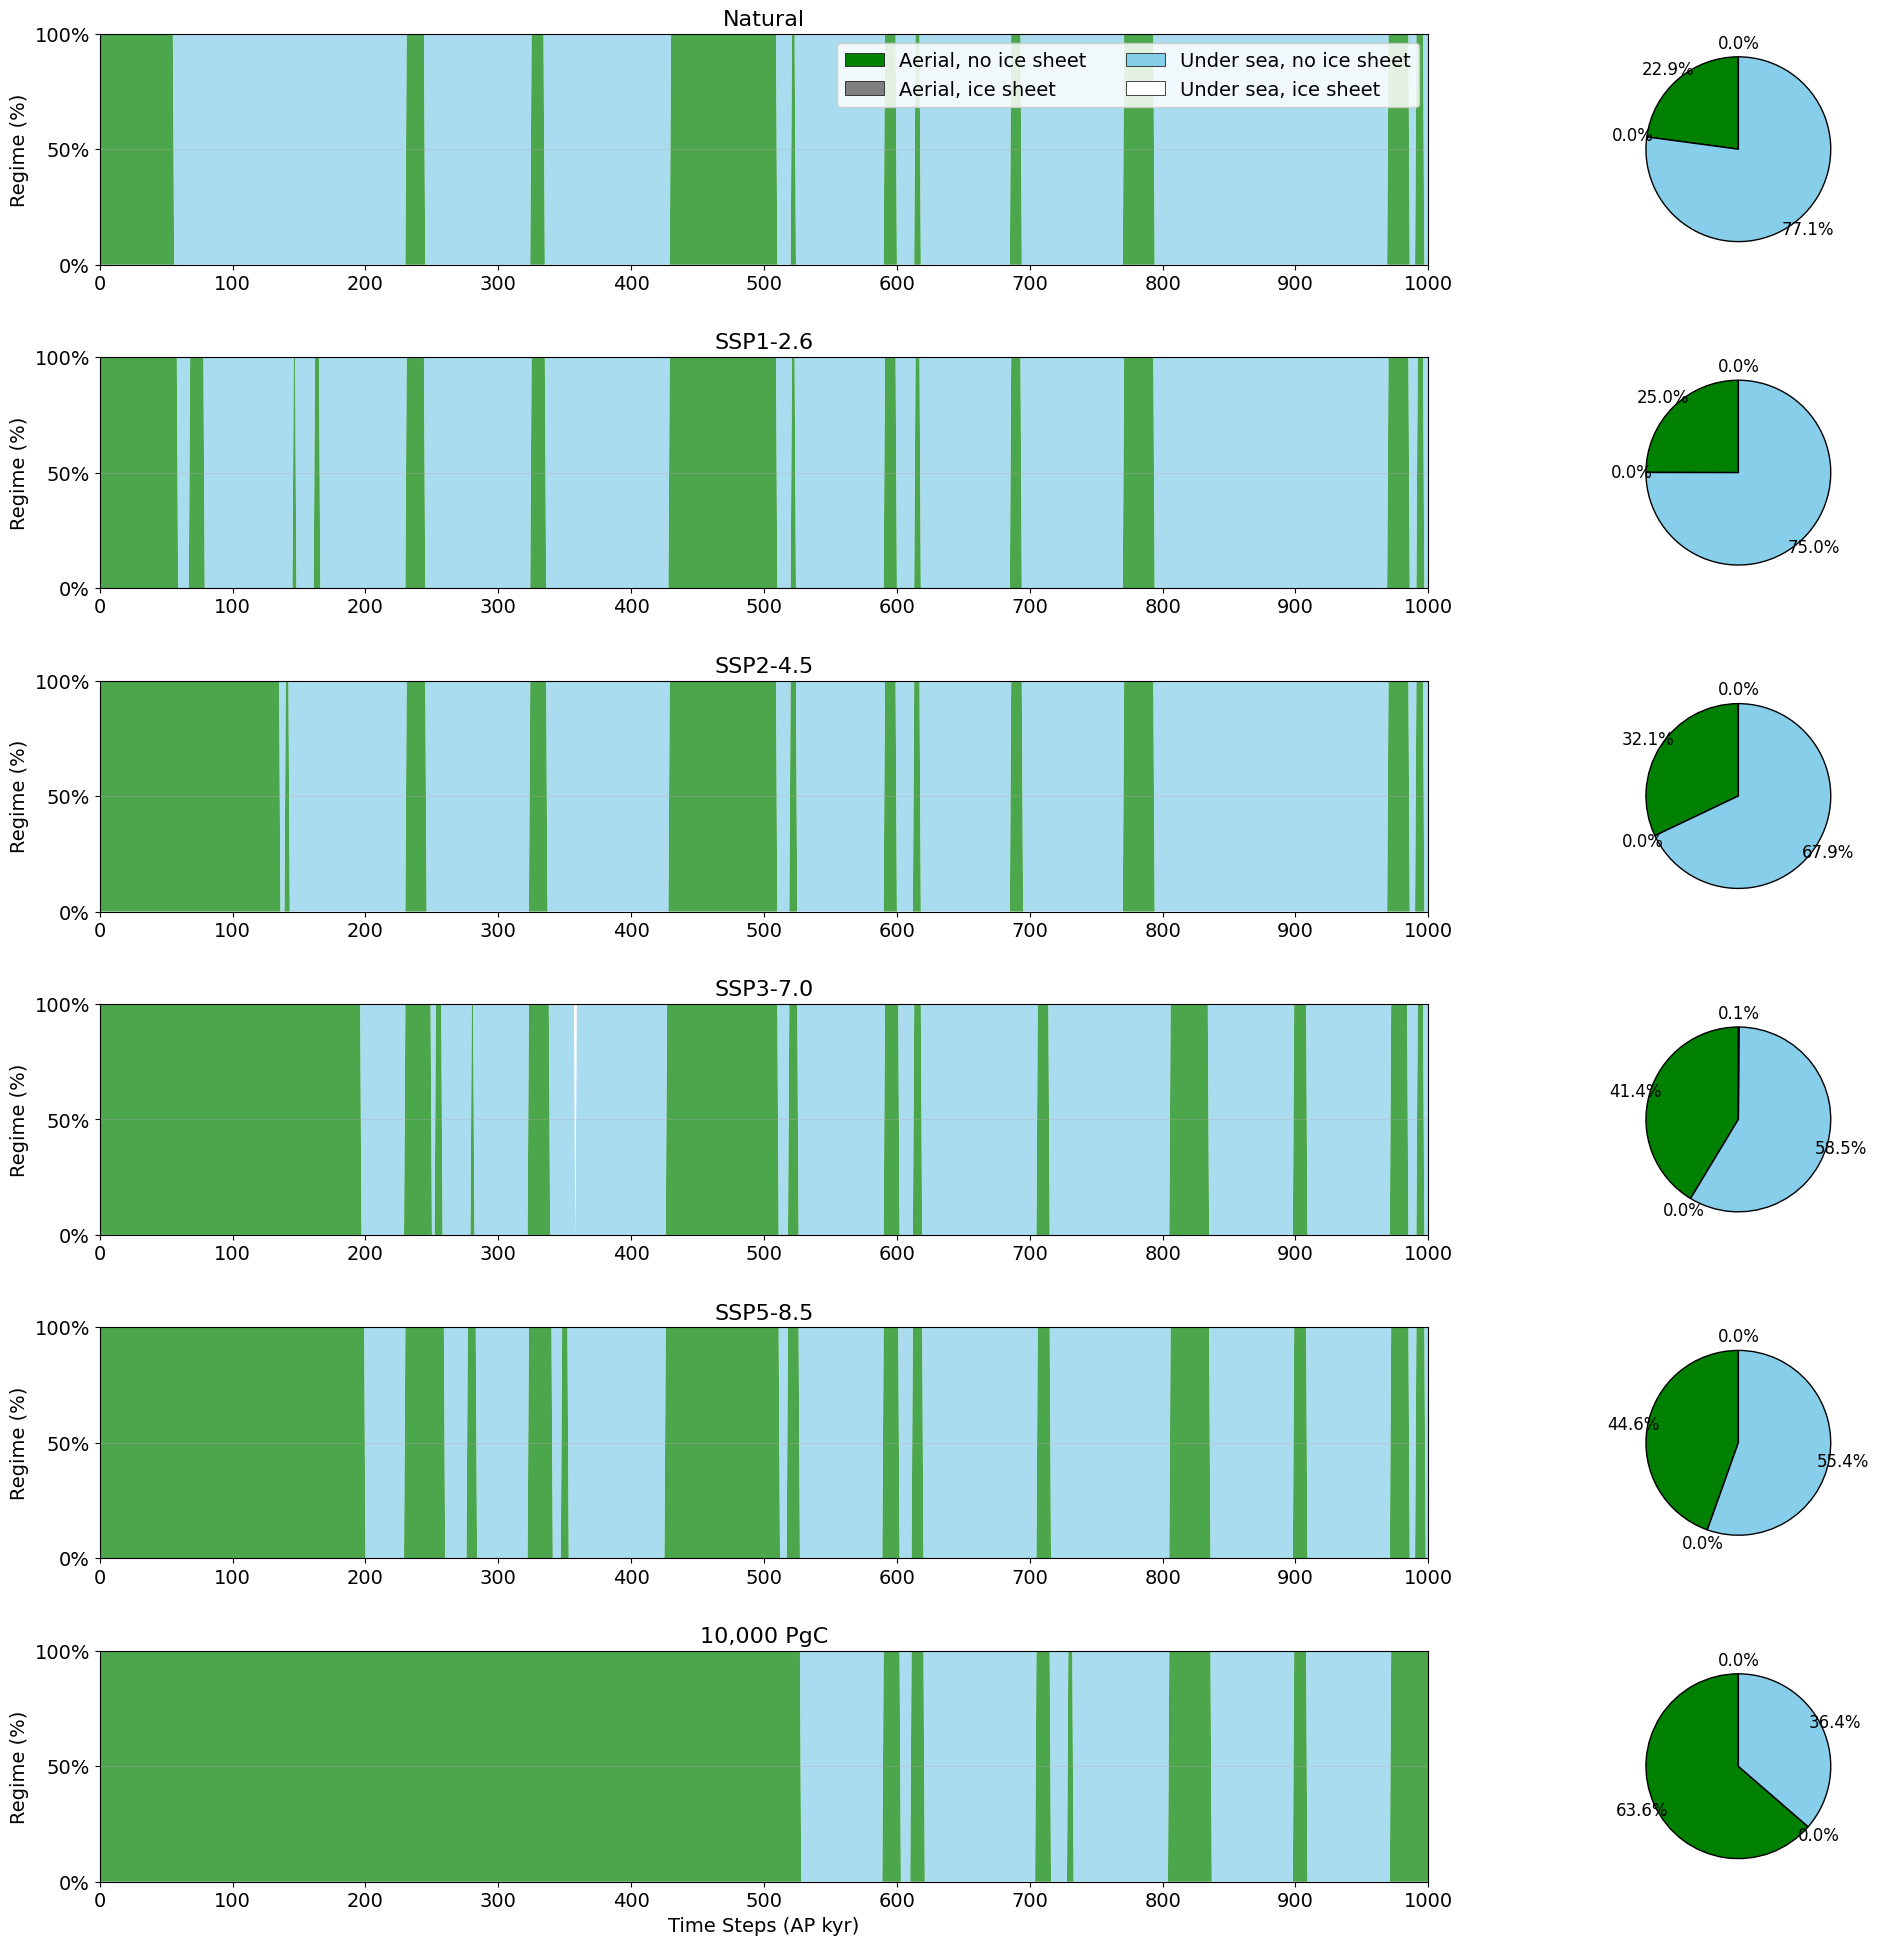

In [35]:
# ── Plot ─────────────────────────────────────────────────────────────────────
n_scen      = len(scenarios)
n_timesteps = regime_member[0].shape[0]   # 1001
time_steps  = np.arange(n_timesteps)

fig = plt.figure(figsize=(24, 4 * n_scen))
gs  = GridSpec(n_scen, 2, figure=fig,
               width_ratios=[3, 1], hspace=0.4, wspace=0.1)

for scen_idx, scen_label in enumerate(scen_labels):
    regime = regime_member[scen_idx]   # (1001,) int 0..3

    # Build 4 binary time series (0 or 100%) for stackplot
    pct = {
        'aerial_noice'   : (regime == REGIME_AERIAL_NOICE  ).astype(float) * 100,
        'aerial_ice'     : (regime == REGIME_AERIAL_ICE    ).astype(float) * 100,
        'undersea_noice' : (regime == REGIME_UNDERSEA_NOICE).astype(float) * 100,
        'undersea_ice'   : (regime == REGIME_UNDERSEA_ICE  ).astype(float) * 100,
    }

    # ── Left: stacked area ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[scen_idx, 0])
    ax1.stackplot(
        time_steps,
        *[pct[k] for k in STACK_ORDER],
        colors=STACK_COLORS,
        alpha=0.7,
        edgecolor='none'
    )

    ax1.set_xlim(0, 1000)
    ax1.set_xticks(time_steps[::100])
    ax1.set_xticklabels(time_steps[::100], fontsize=16)
    ax1.set_ylim(0, 100)
    ax1.set_yticks([0, 50, 100])
    ax1.set_yticklabels(['0%', '50%', '100%'], fontsize=16)
    ax1.tick_params(axis='y', labelsize=16)
    ax1.set_ylabel('Regime (%)', fontsize=25)
    ax1.set_title(scen_label, fontsize=25)
    ax1.grid(axis='y', alpha=0.3)

    if scen_idx == n_scen - 1:
        ax1.set_xlabel('Time Steps (AP kyr)', fontsize=20)

    if scen_idx == 0:
        handles = [
            mpatches.Patch(facecolor=c, edgecolor='black', linewidth=0.5, label=l)
            for c, l in zip(STACK_COLORS, STACK_LABELS)
        ]
        ax1.legend(handles=handles, loc='upper right', fontsize=25,
                   framealpha=0.85, ncol=2)

    # ── Right: pie chart (time fractions) ─────────────────────────────────
    # pctdistance > 1 → labels outside wedge for thin slices
    ax2 = fig.add_subplot(gs[scen_idx, 1])
    pie_vals = [pct[k].sum() for k in STACK_ORDER]
    ax2.pie(
        pie_vals,
        colors=STACK_COLORS,
        autopct='%1.1f%%',
        pctdistance=1.15,
        startangle=90,
        textprops={'fontsize': 12},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )

# fig.suptitle('Ice Sheet Regime at Site LA — Member 67',
#              fontsize=14, y=1.01)

plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved to: {out_path}")
plt.show()